<h4>Tasks</h4>


Question 1 

Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.

In [1]:
# Loading the dataset 
import pandas as pd
df=pd.read_csv("ToyotaCorolla - MLR.csv")
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


Summary Statistics 

In [2]:
# summary statistics
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [3]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


Performing EDA 

In [4]:
# Taking continues variables 
x_conts=df[df.columns[[0,1,2,4,6,10]]]
x_conts

,Price,Age_08_04,KM,HP,cc,Weight
0,13500,23,46986,90,2000,1165
1,13750,23,72937,90,2000,1165
2,13950,24,41711,90,2000,1165
3,14950,26,48000,90,2000,1165
4,13750,30,38500,90,2000,1170
...,...,...,...,...,...,...
1431,7500,69,20544,86,1300,1025
1432,10845,72,19000,86,1300,1015
1433,8500,71,17016,86,1300,1015
1434,7250,70,16916,86,1300,1015


In [5]:
target_var = "Price"
target_var

'Price'

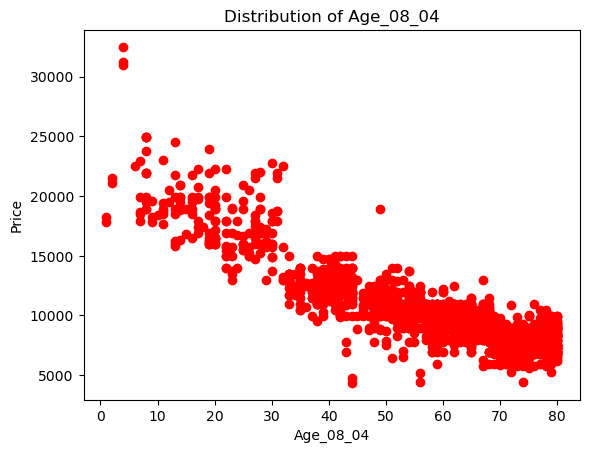

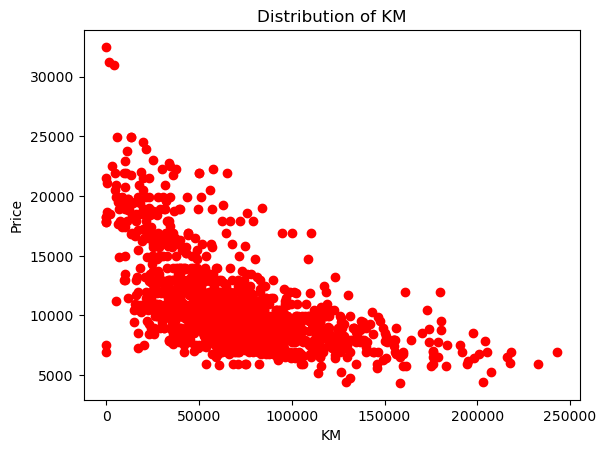

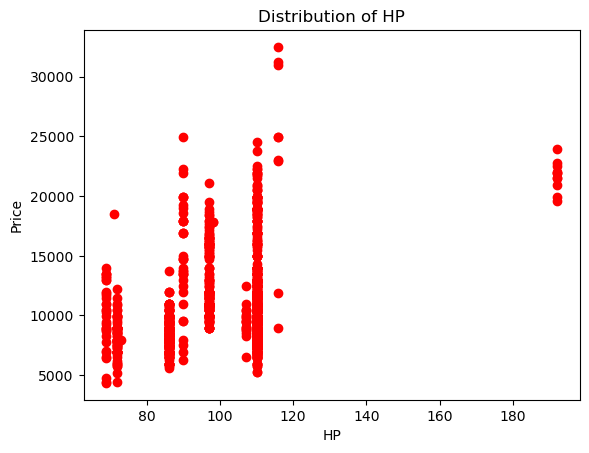

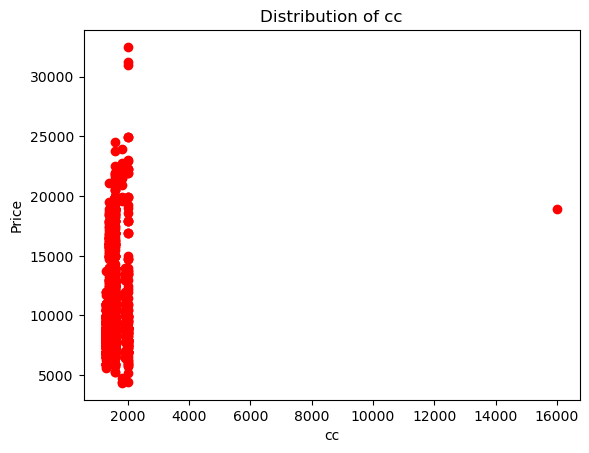

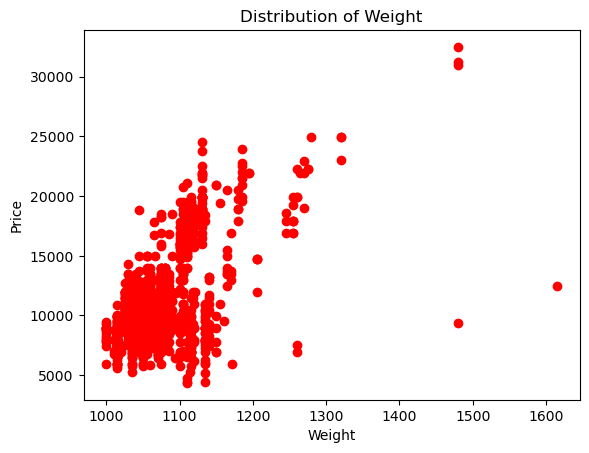

In [6]:
# Performing scatter plot for continous variables
import matplotlib.pyplot as plt
for i in x_conts.select_dtypes(include="number").columns:
    if i != target_var:
        plt.scatter(x = x_conts[i],y= x_conts[target_var],color='red')
        plt.xlabel(i)
        plt.ylabel("Price")
        plt.title(f"Distribution of {i}")
        plt.show()

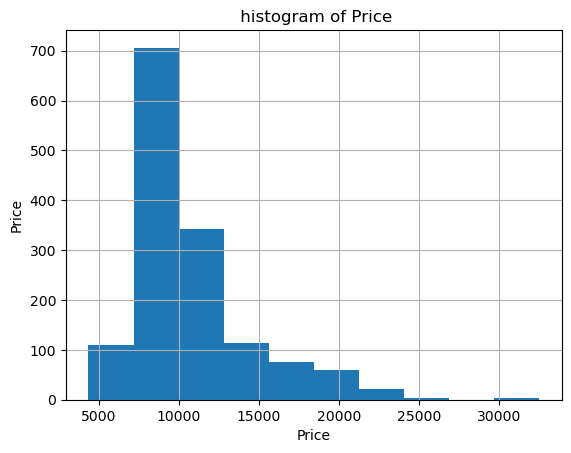

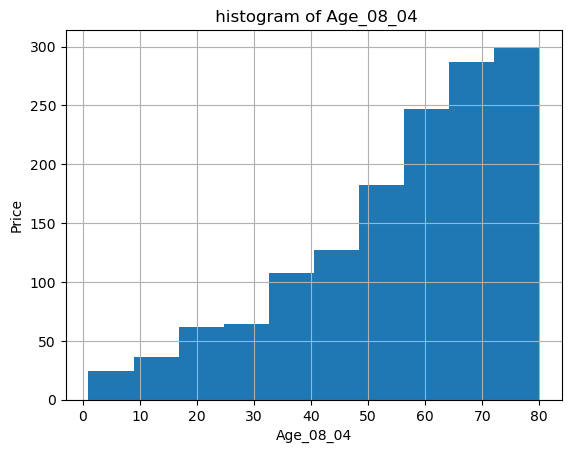

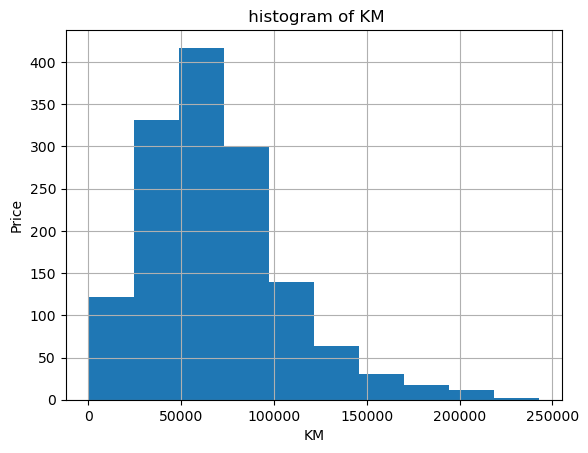

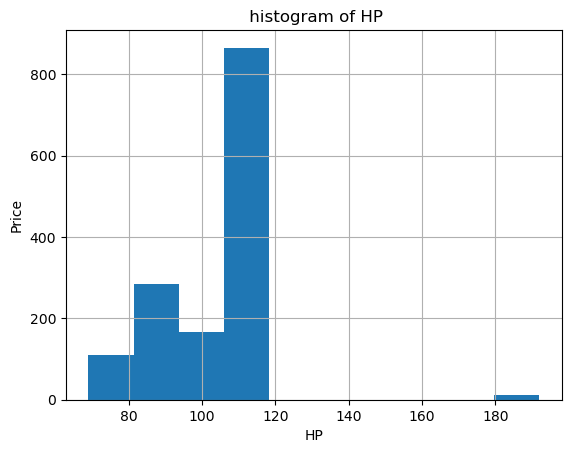

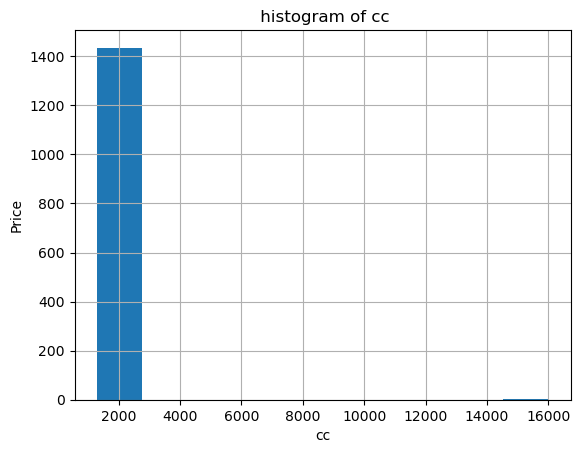

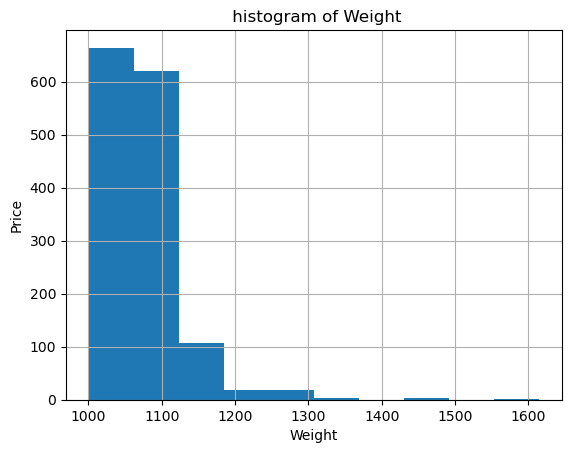

In [7]:
# Performing histogram for continuous variables
for j in x_conts.select_dtypes(include="number").columns:
    x_conts[j].hist()
    plt.xlabel(j)
    plt.ylabel("Price")
    plt.title(f" histogram of {j}")
    plt.show()

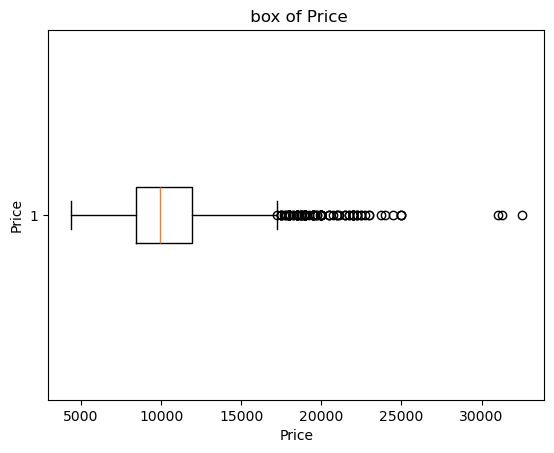

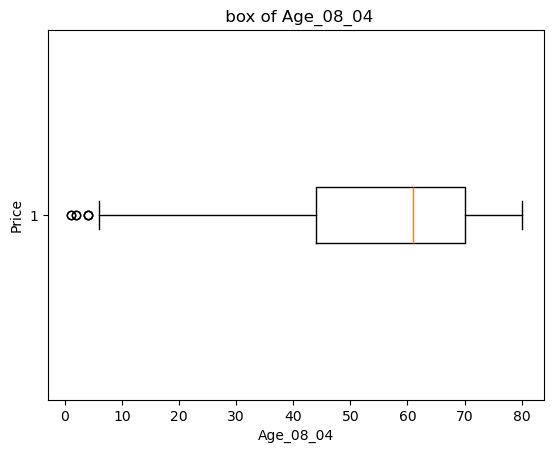

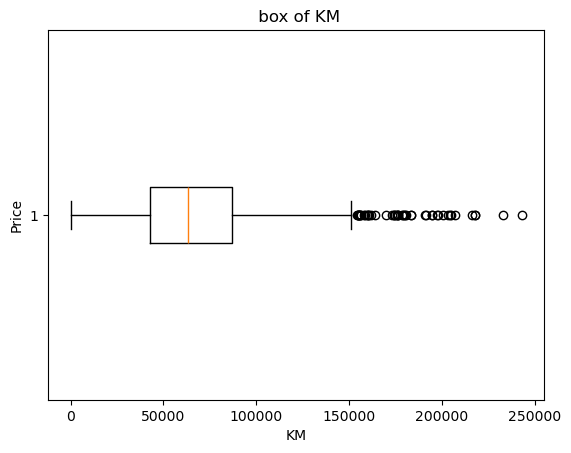

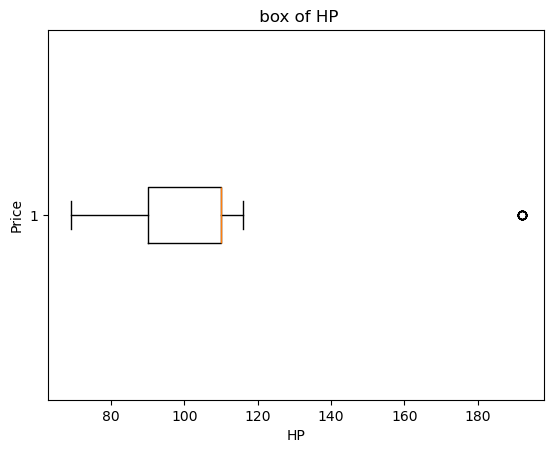

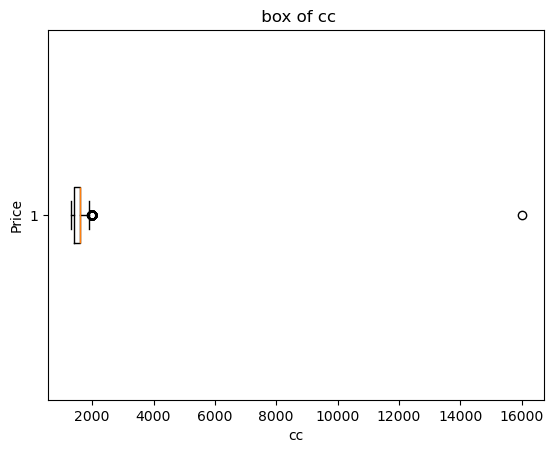

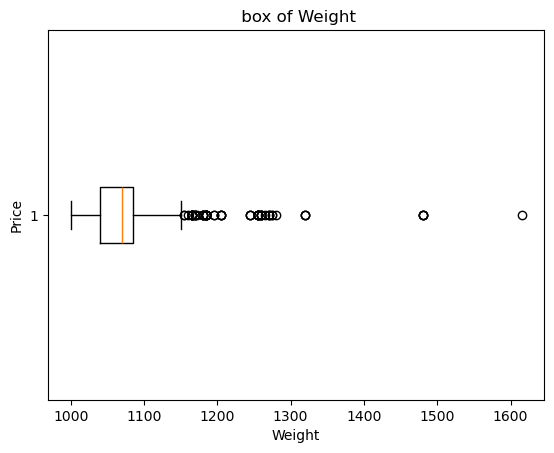

In [8]:
# Performing boxplot for continuous variables
for z in x_conts.select_dtypes(include="number").columns:
    plt.boxplot(x=x_conts[z],vert=False)
    plt.xlabel(z)
    plt.ylabel("Price")
    plt.title(f" box of {z}")
    plt.show()
# Checking outliers by using boxplot 

In [9]:
# Finding nearest wiskers length for the outliers
import numpy as np
for z in x_conts.select_dtypes(include="number").columns:
    Q1 =np.percentile(x_conts[z],25)
    Q3 =np.percentile(x_conts[z],75)
    print("Q1:",Q1)
    print("Q3:",Q3)
    IQR = Q3-Q1
    UW= Q3+(1.5*IQR)
    LW= Q1-(1.5*IQR)
    print("Upper whisker:",UW)
    print("Lower whisker:",LW)
    # outliers idenfication 
    print("Total number of outliers:",len(x_conts[x_conts[z]>UW]))
    print("Total number of outliers:",len(x_conts[x_conts[z]<LW]))

    x_conts.loc[x_conts[z]>UW,z]=UW
    x_conts.loc[x_conts[z]<LW,z]=LW

Q1: 8450.0
Q3: 11950.0
Upper whisker: 17200.0
Lower whisker: 3200.0
Total number of outliers: 110
Total number of outliers: 0
Q1: 44.0
Q3: 70.0
Upper whisker: 109.0
Lower whisker: 5.0
Total number of outliers: 0
Total number of outliers: 7
Q1: 43000.0
Q3: 87020.75
Upper whisker: 153051.875
Lower whisker: -23031.125
Total number of outliers: 49
Total number of outliers: 0
Q1: 90.0
Q3: 110.0
Upper whisker: 140.0
Lower whisker: 60.0
Total number of outliers: 11
Total number of outliers: 0
Q1: 1400.0
Q3: 1600.0
Upper whisker: 1900.0
Lower whisker: 1100.0
Total number of outliers: 123
Total number of outliers: 0
Q1: 1040.0
Q3: 1085.0
Upper whisker: 1152.5
Lower whisker: 972.5
Total number of outliers: 66
Total number of outliers: 0


C:\Users\nannu\AppData\Local\Temp\ipykernel_21076\2348150395.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_conts.loc[x_conts[z]>UW,z]=UW
C:\Users\nannu\AppData\Local\Temp\ipykernel_21076\2348150395.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_conts.loc[x_conts[z]<LW,z]=LW
C:\Users\nannu\AppData\Local\Temp\ipykernel_21076\2348150395.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '153051.875' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  x_conts.loc[x_conts[z]>UW,z]=UW
C:\U

In [10]:
# After applying nearest wisker lengths
# Checking outliers 
import numpy as np
for z in x_conts.select_dtypes(include="number").columns:
    Q1 =np.percentile(x_conts[z],25)
    Q3 =np.percentile(x_conts[z],75)
    print("Q1:",Q1)
    print("Q3:",Q3)
    IQR = Q3-Q1
    UW= Q3+(1.5*IQR)
    LW= Q1-(1.5*IQR)
    print("Upper whisker:",UW)
    print("Lower whisker:",LW)
    # outliers idenfication 
    print("Total number of outliers:",len(x_conts[x_conts[z]>UW]))
    print("Total number of outliers:",len(x_conts[x_conts[z]<LW]))
    

Q1: 8450.0
Q3: 11950.0
Upper whisker: 17200.0
Lower whisker: 3200.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 44.0
Q3: 70.0
Upper whisker: 109.0
Lower whisker: 5.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 43000.0
Q3: 87020.75
Upper whisker: 153051.875
Lower whisker: -23031.125
Total number of outliers: 0
Total number of outliers: 0
Q1: 90.0
Q3: 110.0
Upper whisker: 140.0
Lower whisker: 60.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 1400.0
Q3: 1600.0
Upper whisker: 1900.0
Lower whisker: 1100.0
Total number of outliers: 0
Total number of outliers: 0
Q1: 1040.0
Q3: 1085.0
Upper whisker: 1152.5
Lower whisker: 972.5
Total number of outliers: 0
Total number of outliers: 0


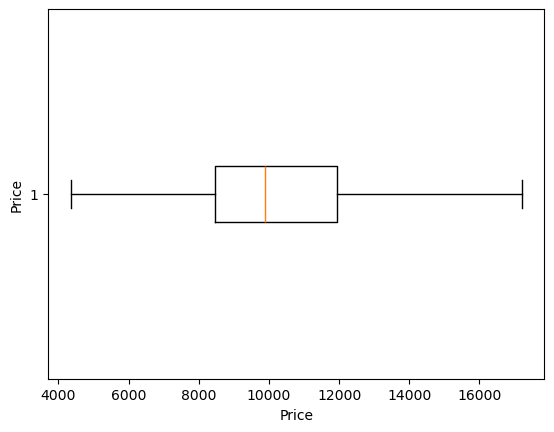

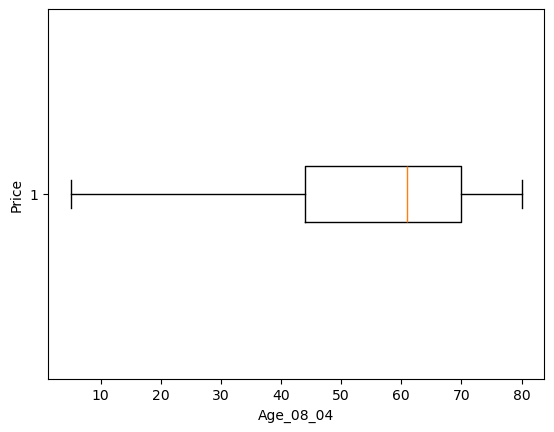

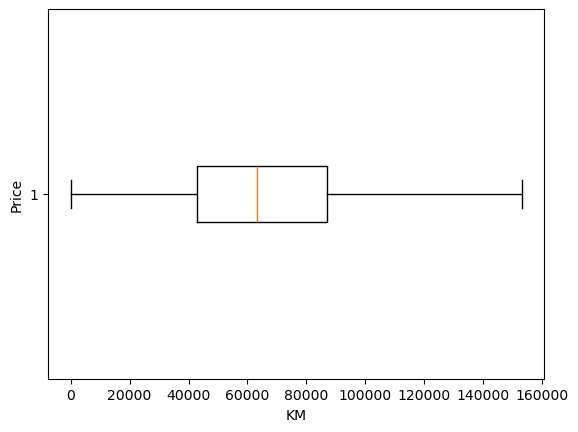

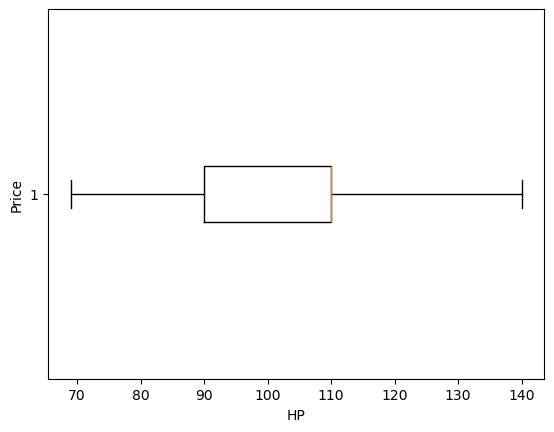

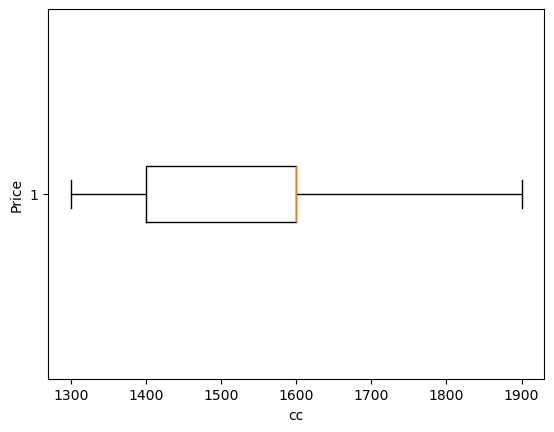

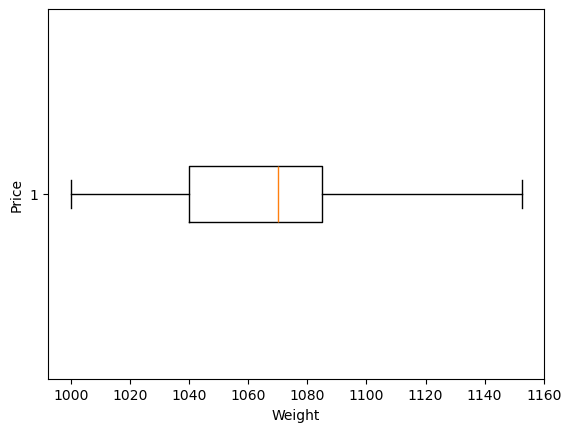

In [11]:
for z1 in x_conts.select_dtypes(include="number").columns:
    plt.boxplot(x=x_conts[z1],vert=False)
    plt.xlabel(z1)
    plt.ylabel("Price")
    plt.show()

Data Visualization for Discreate variables 

In [12]:
# Sperating the discreate variables from dataset
dis=df[df.columns[[3,5,7,9]]]
dis

,Fuel_Type,Automatic,Doors,Gears
0,Diesel,0,3,5
1,Diesel,0,3,5
2,Diesel,0,3,5
3,Diesel,0,3,5
4,Diesel,0,3,5
...,...,...,...,...
1431,Petrol,0,3,5
1432,Petrol,0,3,5
1433,Petrol,0,3,5
1434,Petrol,0,3,5


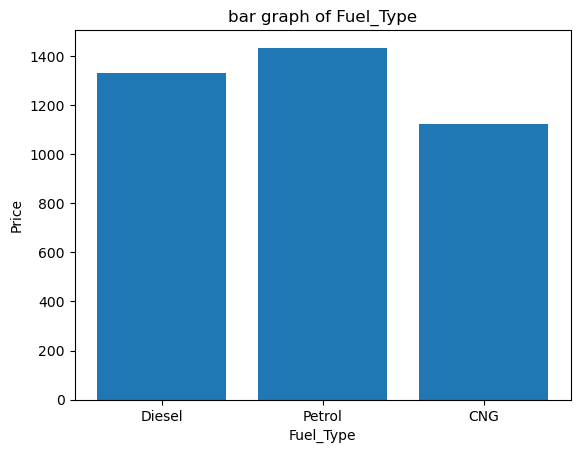

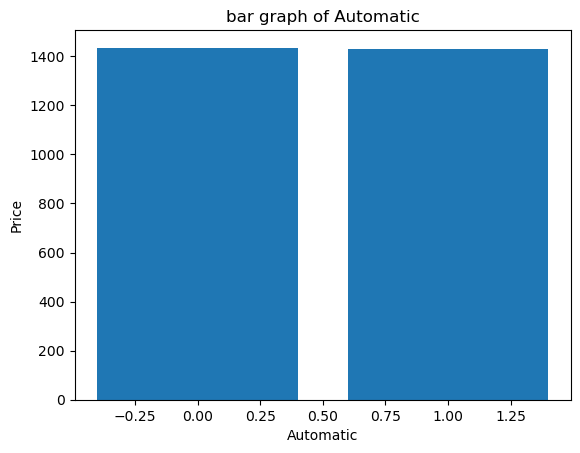

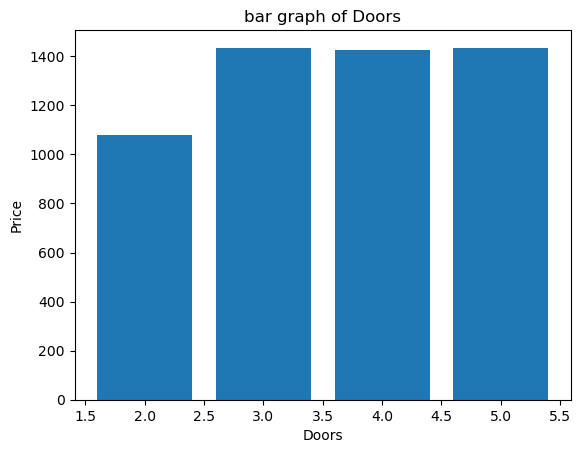

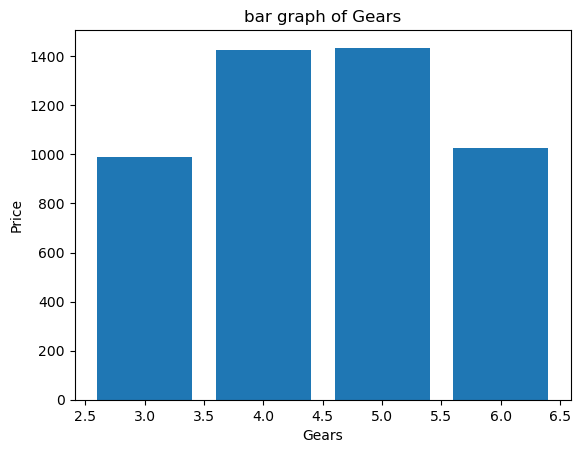

In [13]:
# Performing bar graph for discreate variables 
for a in dis:
    plt.bar(dis[a].values,dis[a].index)
    plt.title(f"bar graph of {a}")
    plt.xlabel(a)
    plt.ylabel("Price")
    plt.show()
    

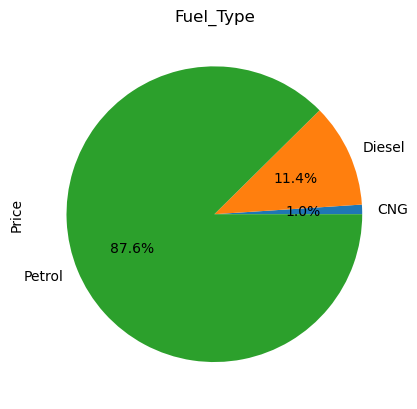

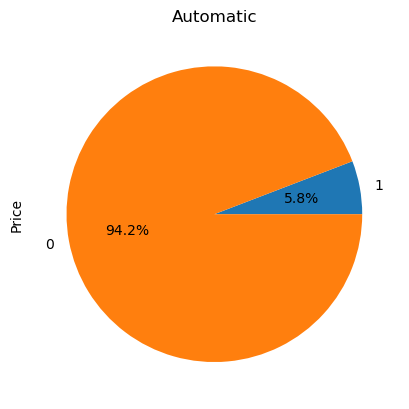

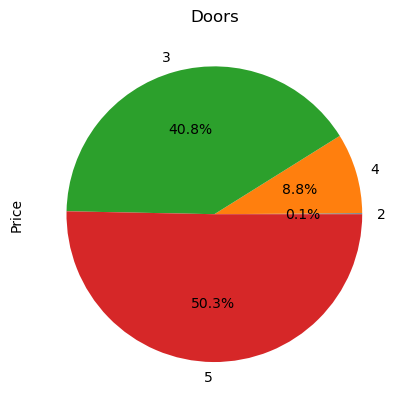

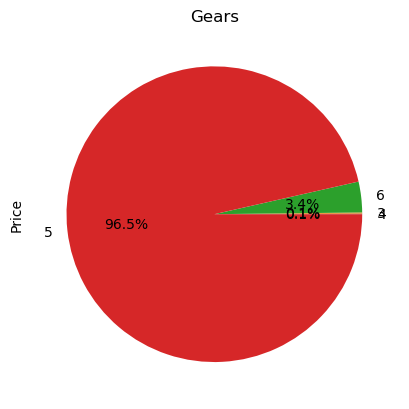

In [14]:
# Performing pie graph for discreate variables 
for b in dis:
    df.groupby(b)["Price"].sum().sort_values(ascending=True).plot(kind='pie',autopct='%1.1f%%')
    plt.title(b)
    plt.show()

Preprocessing 

In [15]:
# Standardization for continuous variables
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X=SS.fit_transform(x_conts)
SS_X=pd.DataFrame(SS_X)
SS_X.columns =list(x_conts)
SS_X

,Price,Age_08_04,KM,HP,cc,Weight
0,1.006237,-1.775799,-0.593750,-0.844850,2.021383,2.222387
1,1.090108,-1.775799,0.153546,-0.844850,2.021383,2.222387
2,1.157205,-1.721920,-0.745652,-0.844850,2.021383,2.222387
3,1.492688,-1.614162,-0.564551,-0.844850,2.021383,2.222387
4,1.090108,-1.398645,-0.838117,-0.844850,2.021383,2.222387
...,...,...,...,...,...,...
1431,-1.006662,0.702643,-1.355186,-1.149198,-1.530776,-1.154070
1432,0.115529,0.864280,-1.399648,-1.149198,-1.530776,-1.418890
1433,-0.671179,0.810401,-1.456780,-1.149198,-1.530776,-1.418890
1434,-1.090533,0.756522,-1.459660,-1.149198,-1.530776,-1.418890


In [16]:
df.columns[[3]]

Index(['Fuel_Type'], dtype='object')

In [17]:
# Sperating the discreate variable to perform LabelEncoding 
df_CC=df[df.columns[[3]]]
df_CC

,Fuel_Type
0,Diesel
1,Diesel
2,Diesel
3,Diesel
4,Diesel
...,...
1431,Petrol
1432,Petrol
1433,Petrol
1434,Petrol


In [18]:
# Applying labelencoding for discreate variables 
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
LE = df_CC.apply(LE.fit_transform)
LE

,Fuel_Type
0,1
1,1
2,1
3,1
4,1
...,...
1431,2
1432,2
1433,2
1434,2


In [19]:
# Combining all the transformation data into a single data frame
df_final=pd.concat((SS_X,LE,df[df.columns[[5,7,9]]]),axis=1)
df_final

,Price,Age_08_04,KM,HP,cc,Weight,Fuel_Type,Automatic,Doors,Gears
0,1.006237,-1.775799,-0.593750,-0.844850,2.021383,2.222387,1,0,3,5
1,1.090108,-1.775799,0.153546,-0.844850,2.021383,2.222387,1,0,3,5
2,1.157205,-1.721920,-0.745652,-0.844850,2.021383,2.222387,1,0,3,5
3,1.492688,-1.614162,-0.564551,-0.844850,2.021383,2.222387,1,0,3,5
4,1.090108,-1.398645,-0.838117,-0.844850,2.021383,2.222387,1,0,3,5
...,...,...,...,...,...,...,...,...,...,...
1431,-1.006662,0.702643,-1.355186,-1.149198,-1.530776,-1.154070,2,0,3,5
1432,0.115529,0.864280,-1.399648,-1.149198,-1.530776,-1.418890,2,0,3,5
1433,-0.671179,0.810401,-1.456780,-1.149198,-1.530776,-1.418890,2,0,3,5
1434,-1.090533,0.756522,-1.459660,-1.149198,-1.530776,-1.418890,2,0,3,5


In [20]:
df_final.corr()

,Price,Age_08_04,KM,HP,cc,Weight,Fuel_Type,Automatic,Doors,Gears
Price,1.000000,-0.895728,-0.608832,0.255640,0.132106,0.509536,0.020635,0.035415,0.184211,0.052827
Age_08_04,-0.895728,1.000000,0.531839,-0.131284,-0.139771,-0.478225,0.080329,0.031619,-0.148137,-0.005463
KM,-0.608832,0.531839,1.000000,-0.330495,0.255855,-0.001489,-0.394674,-0.081882,-0.037677,0.019974
HP,0.255640,-0.131284,-0.330495,1.000000,0.099605,0.026578,0.455845,0.022339,0.120844,0.140602
cc,0.132106,-0.139771,0.255855,0.099605,1.000000,0.718655,-0.599662,-0.059519,0.139616,0.051949
Weight,0.509536,-0.478225,-0.001489,0.026578,0.718655,1.000000,-0.530964,0.090064,0.381955,0.019913
Fuel_Type,0.020635,0.080329,-0.394674,0.455845,-0.599662,-0.530964,1.000000,0.069718,-0.026935,0.069655
Automatic,0.035415,0.031619,-0.081882,0.022339,-0.059519,0.090064,0.069718,1.000000,-0.027654,-0.098555
Doors,0.184211,-0.148137,-0.037677,0.120844,0.139616,0.381955,-0.026935,-0.027654,1.000000,-0.160141
Gears,0.052827,-0.005463,0.019974,0.140602,0.051949,0.019913,0.069655,-0.098555,-0.160141,1.000000


Question 2

Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [28]:
# Sperating the x and y variables
x=df_final.drop("Price",axis=1)
y=df_final["Price"]
y

0       1.006237
1       1.090108
2       1.157205
3       1.492688
4       1.090108
          ...   
1431   -1.006662
1432    0.115529
1433   -0.671179
1434   -1.090533
1435   -1.191178
Name: Price, Length: 1436, dtype: float64

In [29]:
# Spliting the dataset into training and testing data 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Question 3

Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [30]:
# Fitting the model for training dataset
# Building a model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)

In [31]:
model.coef_

array([-0.66569161, -0.1720397 ,  0.0808762 , -0.10359104,  0.3119452 ,
        0.18759229,  0.00807052, -0.0251824 ,  0.16806314])

In [32]:
model.intercept_

np.float64(-1.0916349923873276)

Question 4

Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [33]:
import numpy as np
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score

mse_train = mean_squared_error(y_train,y_pred_train)
mse_test = mean_squared_error(y_test,y_pred_test)
print("Train Mean squared error:",np.round(mse_train,2))
print("Test Mean squared error:",np.round(mse_test,2))

rmse_train = root_mean_squared_error(y_train,y_pred_train)
rmse_test = root_mean_squared_error(y_test,y_pred_test)
print("Train Root Mean squared error: ",np.round(rmse_train,2))
print("Test Root Mean squared error: ",np.round(rmse_test,2))

r2_train = r2_score(y_train,y_pred_train)
r2_test = r2_score(y_test,y_pred_test)
print("Train R square: ",np.round(r2_train,2))
print("Test R square: ",np.round(r2_test,2))


Train Mean squared error: 0.13
Test Mean squared error: 0.13
Train Root Mean squared error:  0.37
Test Root Mean squared error:  0.36
Train R square:  0.87
Test R square:  0.86


Question 5 

Apply Lasso and Ridge methods on the model.

Lasso Regression

In [35]:
# Applying the cross validation 
from sklearn.model_selection import ShuffleSplit,cross_validate
ss=ShuffleSplit(n_splits=500,test_size=0.2,random_state=42)
cv=cross_validate(model,x,y,cv=ss,scoring="r2",return_train_score=True)

train_scores=cv["train_score"]
test_scores=cv["test_score"]

print(f"cross_validation : train_score: {np.round(train_scores.mean(),2)}")
print(f"cross_validation : test_score: {np.round(test_scores.mean(),2)}")


cross_validation : train_score: 0.87
cross_validation : test_score: 0.86


In [36]:
# Finding the best mse and alpha values for lasso
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import ShuffleSplit

sss=ShuffleSplit(n_splits=100,test_size=0.2,random_state=42)

locv=LassoCV(cv=sss,random_state=42)
locv.fit(x,y)

best_alpha_locv=locv.alpha_
mse_path=locv.mse_path_
mean_mse=mse_path.mean(axis=1)
best_mse=mean_mse[locv.alphas_== best_alpha_locv][0]

print("best alpha value:",best_alpha_locv)
print("mean squared error for best alpha: ",best_mse)

best alpha value: 0.0008957279230967027
mean squared error for best alpha:  0.1351580708710809


In [37]:
# Fitiing the model with lasso by using best alpha values.
from sklearn.linear_model import Lasso

final_lasso_model=Lasso(alpha=best_alpha_locv)
final_lasso_model.fit(x,y)

lasso_coefficients = final_lasso_model.coef_

zero_coefficients = np.sum(lasso_coefficients==0)
non_zero_coefficients=np.sum(lasso_coefficients!=0)

# Showing the no of variables near to the variables.
print("number of zero coeff: ",zero_coefficients)
print("no of non zero coeff: ",non_zero_coefficients)

number of zero coeff:  0
no of non zero coeff:  9


In [38]:
# Calculating the accuracy score by using lasso model.
from sklearn.model_selection import ShuffleSplit,cross_validate

s2=ShuffleSplit(n_splits=500,test_size=0.2,random_state=42)

cvs=cross_validate(final_lasso_model,x,y,cv=s2,scoring="r2",return_train_score=True)

train_scores=cvs["train_score"]
test_scores=cvs["test_score"]

print(f"Traing Score:  {np.round(train_scores.mean(),2)}")
print(f"Test Score:  {np.round(test_scores.mean(),2)}")

Traing Score:  0.87
Test Score:  0.86


Ridge Regression

In [39]:
# Finding the best alpha value for ridge regression
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import ShuffleSplit

ss2=ShuffleSplit(n_splits=100,test_size=0.2,random_state=42)

alphas = np.logspace(-3, 3, 50)

rdg = RidgeCV(alphas=alphas, cv=ss2, scoring="neg_mean_squared_error")
rdg.fit(x, y)

best_alpha_rdg=rdg.alpha_

print("best alpha value:",best_alpha_rdg)

best alpha value: 2.6826957952797246


In [40]:
# Fitting the model with best alpha value for ridge regression.
from sklearn.linear_model import Ridge

final_ridge_model = Ridge(alpha=best_alpha_rdg)
final_ridge_model.fit(x, y)

ridge_coefficients = final_ridge_model.coef_

zero_coefficients = np.sum(ridge_coefficients == 0)
non_zero_coefficients = np.sum(ridge_coefficients != 0)

print("Number of Zero Coefficients: ", zero_coefficients)
print("Number of Non-Zero Coefficients: ", non_zero_coefficients)

Number of Zero Coefficients:  0
Number of Non-Zero Coefficients:  9


In [41]:
# Calculating the accuracy score for ridge regression.
from sklearn.model_selection import ShuffleSplit,cross_validate

s2=ShuffleSplit(n_splits=500,test_size=0.2,random_state=42)

cvs=cross_validate(final_ridge_model,x,y,cv=s2,scoring="r2",return_train_score=True)

train_scores=cvs["train_score"]
test_scores=cvs["test_score"]

print(f"Traing Score:  {np.round(train_scores.mean(),2)}")
print(f"Test Score:  {np.round(test_scores.mean(),2)}")

Traing Score:  0.87
Test Score:  0.86


Interview Questions:

1.What is Normalization & Standardization and how is it helpful

Normalization(scaling):

It does not remove the units but it will adjust the values in the range of 0 to 1.

==>It preserves the shape of the orginal distributions.

==>Helpfull for gradient based methods preferred for: KNN,K-Means,SVM.

==>Beacuse this algorithms works based on distance metrices so that it calculates in the form of 0 and 1.

Standardization(z_score): 

==>When outliers are existed this transformation can be used because it works on mean and std.so the distribution can be expanded from the center to a point.

==>Standardization values are in the range of -3 to +3.preferred for linear regression ,Logestic Regression.

==>Because this assumes the data is in noraml distribution.

2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicolinarity :

Multicolinaerity occurs when independent variables are highly correlated with each other.which means

==> Between x and y variables we want to have a strong relationship .bw x and x variables if having a strong relationship then it leads to a multicolinarity.

==>It does not affect the model's ability to predict, but it creates problems in understanding which variables actually influences the target.

Detecting outliers :

1.Correlation Matrix :

==>df.corr() which measures the strength and direection of a linear relationship between 2 variables.

2.Varience inflation Factor :
==>if vif values are: 

==>vif<5 --> no multicollinearity issues, accept to fit the model.

==>vif to 10--> slightly multi collinearity.

==>vif > 10 --> variables are ignored cuz having high multicollinearity.

The techniques can be used to address multicollinearity in multiple linear regression :

1.Regression techniques
2.Principle component analysis(PCA)

3. Include any assumptions made during the analysis and discuss their implications.

==> The target variable must be continious or numeric.

==> Linear relationship should exist between x and y by checking with scatter plot

==> Varience should be in consistent(homoscedasticity).

==> No Multicollinearity issues should have, check with vif

==> x variables are to be followed normal distributions.